In [1]:
from pathlib import Path
import sys

# Get the absolute path of the parent directory
parent_dir = str(Path(".").resolve().parent)

# Add it to the system path
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms.v2 as transforms_v2
import pydicom as dicom
import pandas as pd
import numpy as np
import optuna
from sklearn.model_selection import train_test_split
import skimage
import scipy
import pandas as pd

import cbis
import camvid
import metrics
import unet
import segnet
import fcn
import albumentations as A

import matplotlib.pyplot as plt

# Testing

In [55]:
DATA_PATH = "/home/gianluca/Downloads/CamVid"

mean_values = (0.485, 0.456, 0.406)
std_values = (0.229, 0.224, 0.225)

transforms = A.Compose(
    [
        A.RandomResizedCrop(size=(224, 224)),
        A.HorizontalFlip(p=0.5),
        A.Normalize(mean=mean_values, std=std_values)
    ]
)

train_dataset = camvid.CAMVID_Dataset(f"{DATA_PATH}/train", f"{DATA_PATH}/train_labels", f"{DATA_PATH}/class_palette.csv", transform=transforms)
val_dataset = camvid.CAMVID_Dataset(f"{DATA_PATH}/val", f"{DATA_PATH}/val_labels", f"{DATA_PATH}/class_palette.csv", transform=transforms)
test_dataset = camvid.CAMVID_Dataset(f"{DATA_PATH}/test", f"{DATA_PATH}/test_labels", f"{DATA_PATH}/class_palette.csv")

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=4,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

In [56]:
it = iter(train_dataloader)
X, y = next(it)

In [57]:
model = fcn.FCN(in_channels=3, out_channels=11)

In [58]:
X.dtype

torch.float32

In [63]:
logits = model(X)

In [64]:
loss_fn = nn.CrossEntropyLoss(ignore_index=11)
loss_fn(logits, y)

tensor(2.3979, grad_fn=<NllLoss2DBackward0>)

In [8]:
y.size()

torch.Size([4, 224, 224])

In [10]:
pred.size()

torch.Size([4, 11, 224, 224])

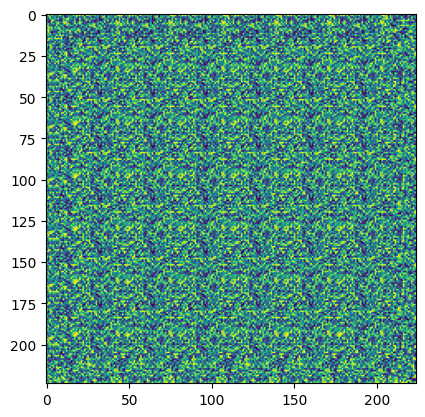

In [13]:
plt.imshow(pred.argmax(dim=1)[0])

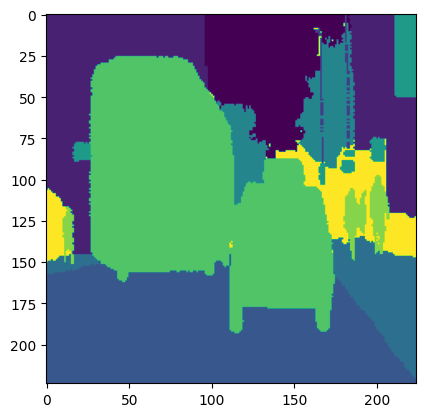

In [45]:
plt.imshow(y[1])

/tmp/ipykernel_103199/3651802379.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  img_to_show = (image * std) + mean


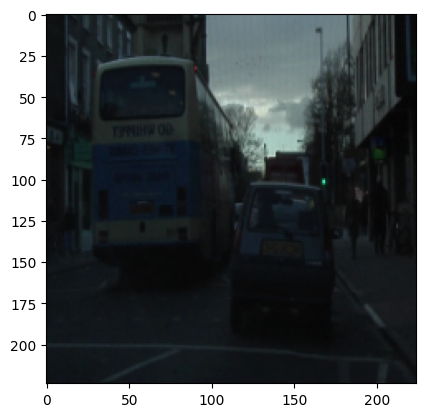

In [53]:
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image = X[1].permute((1,2,0))
# Reverse the transformation and clip to safety
img_to_show = (image * std) + mean
img_to_show = np.clip(img_to_show, 0, 1)

plt.imshow(img_to_show)

In [2]:
device = "cpu"
random_state=0
data_root_filepath = "/run/media/gianluca/EXTERNAL_US/CBIS-DDSM" # path to the root folder of the data
batch_size=2

# defining transforms to augment data
transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=270, p=1.0)
])

# keeping only MLO and masses
df = pd.read_csv(f"{data_root_filepath}/lesions.csv")
df = df[
    (df["image view"] == "MLO") & 
    (df["kind"] == "Mass")
]

# dividing data in test and train data
df_train_val, df_test = train_test_split(df, test_size=0.1,random_state=random_state)

# divide data in training and validation set
df_train, df_val = train_test_split(df_train_val, test_size=0.22, random_state=random_state)

trainval_data = cbis.CBIS_Dataset(data_root_filepath, df_train_val, transform=transforms)
test_data = cbis.CBIS_Dataset(data_root_filepath, df_test)

trainval_dataloader = DataLoader(
        dataset=trainval_data,
        batch_size=batch_size,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True
    )
test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=batch_size,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

model = unet.UNet(n_class=2)
checkpoint = torch.load(
    "/home/gianluca/Desktop/20260620_133417/final_model/checkpoints/checkpoint_46.pth", 
    weights_only=True, 
    map_location=torch.device('cpu')
)
model.load_state_dict(checkpoint['model_state_dict'])

loss_fn = metrics.DiceLoss()

In [3]:
it = iter(trainval_dataloader)

In [4]:
X, y = next(it)
logits = model(X)

In [5]:
preds = torch.sigmoid(logits)

In [7]:
loss = nn.BCELoss()
loss(preds, (y>0).float())

tensor(1.1298, grad_fn=<BinaryCrossEntropyBackward0>)

In [23]:
X, y = next(it)
logits = model(X)
pred_probs = torch.softmax(logits, dim=1)

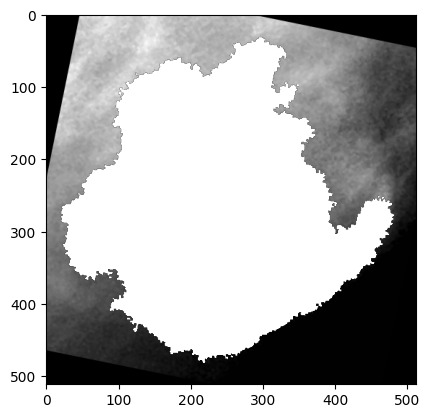

In [24]:
i = 0
plt.imshow(X[i,0], cmap="gray")
plt.imshow(y[i,1], cmap="gray", alpha=(y[i,1] > 0).float())

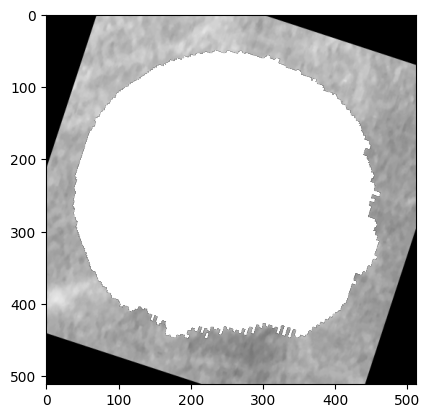

In [27]:
i = 1
plt.imshow(X[i,0], cmap="gray")
plt.imshow(y[i,1], cmap="gray", alpha=(y[i,1] > 0).float())

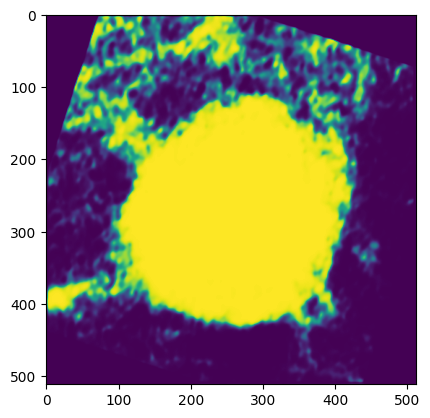

In [28]:
plt.imshow(pred_probs.detach()[i,1])

In [14]:
loss_fn = metrics.DiceLoss()
loss = loss_fn(y.float(), pred_probs).item()
print(loss)

0.5108447074890137
